#DEEP NEURAL NETWORKS
---

##0.REFERENCE

**Notebook title: Deep Neural Networks for Handwritten Digit Recognition**

**Introduction**

The handwritten digits problem is one of the classic entry points into deep neural networks because it is small enough to understand, visual enough to inspect, and rich enough to show the essential logic of supervised learning. Each observation is an image of a handwritten digit, and the task is to teach a model to recognize whether the image represents a zero, one, two, three, four, five, six, seven, eight, or nine. This is not merely a toy problem. It contains, in miniature, many of the same conceptual elements that appear in larger machine learning systems: numerical representation of raw data, feature scaling, train and test separation, model architecture, loss functions, optimization, validation, evaluation, error analysis, and interpretation of results.

In this notebook, we use the classical digits dataset from scikit-learn. Each image is an 8 by 8 grayscale matrix, meaning that every digit is represented by 64 numerical pixel values. A human sees a small image. The model sees a vector of numbers. The deep neural network must learn how patterns in those numbers correspond to symbolic categories. For example, a loop in the upper part of the image may help distinguish a 9 from a 4, while two stacked loops may help distinguish an 8 from a 3. The model does not receive these rules explicitly. It discovers useful internal representations by adjusting its weights during training.

The architecture used here is a simple fully connected deep neural network. It is not a convolutional neural network, because the pedagogical objective is to teach the basic anatomy of a neural network before introducing spatial filters and convolutional layers. The model receives 64 scaled input values, passes them through several hidden layers with nonlinear activation functions, and produces a probability distribution over the ten possible digit classes. The final prediction is the class with the highest predicted probability.

The notebook follows a strict 10 implementation cell structure. Each cell performs one conceptual step. The sequence begins with environment setup and data loading, then moves to visualization, preprocessing, dataset construction, model definition, training, evaluation, prediction inspection, and artifact export. After the implementation cells, we include one additional cell that uses an OpenAI language model to generate a structured explanation of the model and results. This is important because modern machine learning practice increasingly combines numerical modeling with governed narrative interpretation. The model computes; the LLM explains; the human reviews.

The purpose of this notebook is not to maximize accuracy at all costs. The purpose is to teach the complete workflow of a deep learning experiment in a clean, auditable, and reproducible way. Students should be able to run the notebook end to end, inspect every intermediate object, understand why each step exists, and connect the final accuracy and confusion matrix back to the underlying learning problem. The digits problem is quintessential because it turns abstract neural network theory into something students can see, train, evaluate, and explain.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This first implementation cell prepares the notebook environment. It imports the libraries used throughout the experiment, fixes random seeds for reproducibility, creates folders for outputs, and records a simple run identifier. The goal is to make the experiment orderly and auditable. A deep learning notebook should not begin directly with model training. It should first define its environment, its output structure, and the basic controls that make results easier to reproduce.

In [1]:
import os
import json
import random
import platform
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path("/content/dnn_digits_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("Artifacts folder:", ARTIFACT_DIR)

Run ID: run_20260604_125547_utc
TensorFlow version: 2.20.0
Artifacts folder: /content/dnn_digits_project/artifacts


##2.THE HANDWRITTEN DATA SET

**Explanation for Cell 2**

This cell loads the handwritten digits dataset. The dataset contains small 8 by 8 grayscale images. Each image has a label from 0 to 9. We inspect the shape of the image array, the shape of the flattened data matrix, and the distribution of labels. This step teaches students that machine learning begins by understanding the structure of the data before building any model.

In [2]:
digits = load_digits()

images = digits.images
X_raw = digits.data
y = digits.target
class_names = [str(i) for i in range(10)]

dataset_summary = {
    "number_of_samples": int(X_raw.shape[0]),
    "number_of_features": int(X_raw.shape[1]),
    "image_shape": list(images.shape[1:]),
    "number_of_classes": int(len(np.unique(y))),
    "classes": class_names
}

label_counts = {
    str(label): int(count)
    for label, count in zip(*np.unique(y, return_counts=True))
}

print("Dataset summary")
print(json.dumps(dataset_summary, indent=2))

print("\nLabel counts")
print(json.dumps(label_counts, indent=2))

Dataset summary
{
  "number_of_samples": 1797,
  "number_of_features": 64,
  "image_shape": [
    8,
    8
  ],
  "number_of_classes": 10,
  "classes": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
  ]
}

Label counts
{
  "0": 178,
  "1": 182,
  "2": 177,
  "3": 183,
  "4": 181,
  "5": 182,
  "6": 181,
  "7": 179,
  "8": 174,
  "9": 180
}


##3.VISUALIZATION

**Explanation for Cell 3**

This cell visualizes examples from the dataset. The digits problem is especially useful for teaching because students can see the original inputs. The model will only receive numbers, but the human can inspect the images visually. This helps connect the mathematical representation of the data with the real-world object being classified.

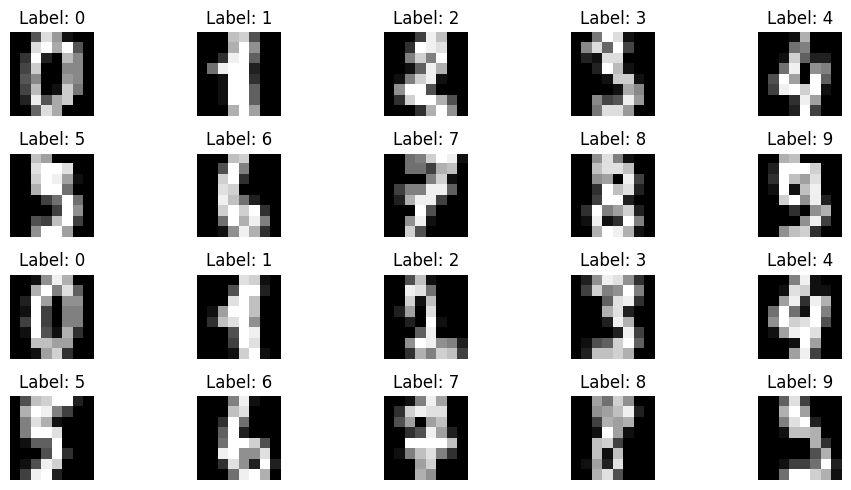

Saved sample grid to: /content/dnn_digits_project/artifacts/sample_digit_grid.png


In [3]:
fig = plt.figure(figsize=(10, 5))

for i in range(20):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()

sample_grid_path = ARTIFACT_DIR / "sample_digit_grid.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved sample grid to:", sample_grid_path)

##4.NEURAL NETWORK FOR TRAINING

In [4]:
X_scaled = X_raw.astype("float32") / 16.0

y_onehot = keras.utils.to_categorical(y, num_classes=10)

X_train_full, X_test, y_train_full, y_test, y_train_full_onehot, y_test_onehot = train_test_split(
    X_scaled,
    y,
    y_onehot,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val, y_train_onehot, y_val_onehot = train_test_split(
    X_train_full,
    y_train_full,
    y_train_full_onehot,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

split_summary = {
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "input_features": int(X_train.shape[1])
}

print("Split summary")
print(json.dumps(split_summary, indent=2))

Split summary
{
  "training_samples": 1149,
  "validation_samples": 288,
  "test_samples": 360,
  "input_features": 64
}


##5.USING TENSORFLOW

In [5]:
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train_onehot))
    .shuffle(buffer_size=len(X_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val_onehot))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test_onehot))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_X, batch_y in train_ds.take(1):
    print("Feature batch shape:", batch_X.shape)
    print("Label batch shape:", batch_y.shape)

Feature batch shape: (32, 64)
Label batch shape: (32, 10)


##6.CONFIGURATION OF THE NEURAL NETWORK

**Explanation for Cell 6**

This cell defines the deep neural network. The model receives 64 input features, corresponding to the 64 pixels in each 8 by 8 image. It then passes the input through several dense layers. The ReLU activation function introduces nonlinearity, allowing the model to learn patterns more complex than a straight-line classifier. Dropout is included as a simple regularization technique. The final layer has 10 units and uses softmax, producing one probability for each digit class.

In [6]:
def build_digits_dnn(input_dim=64, num_classes=10):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(32, activation="relu"),
            layers.Dense(num_classes, activation="softmax")
        ],
        name="deep_neural_network_digits_classifier"
    )
    return model

model = build_digits_dnn(
    input_dim=X_train.shape[1],
    num_classes=10
)

model.summary()

Model: "deep_neural_network_digits_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,986 (74.16 KB)

 Trainable params: 18,986 (74.16 KB)

 Non-trainable params: 0 (0.00 B)

##7.COMPILATION AND TRAINING

**Explanation for Cell 7**

This cell compiles and trains the neural network. Compilation defines the optimizer, the loss function, and the metrics. The Adam optimizer adjusts the weights during training. Categorical cross-entropy measures the difference between the predicted probability distribution and the true one-hot encoded label. Accuracy provides an intuitive performance measure. Early stopping protects against unnecessary training once validation performance stops improving.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

history_dict = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

history_path = ARTIFACT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Training history saved to:", history_path)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2802 - loss: 2.1430 - val_accuracy: 0.5139 - val_loss: 1.7759
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5788 - loss: 1.4786 - val_accuracy: 0.8264 - val_loss: 0.8745
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7659 - loss: 0.8211 - val_accuracy: 0.8854 - val_loss: 0.4814
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8285 - loss: 0.5777 - val_accuracy: 0.9306 - val_loss: 0.3023
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8686 - loss: 0.4286 - val_accuracy: 0.9410 - val_loss: 0.2316
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9008 - loss: 0.3541 - val_accuracy: 0.9583 - val_loss: 0.1885
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9051 - loss: 0.2974 - val_accuracy: 0.9653 - val_loss: 0.1555
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9252 - loss: 0.2488 - val_accuracy: 0.9722 - 

##8.VISUALIZATION OF THE TRAINING PROCESS

**Explanation for Cell 8**

This cell visualizes the training process. The loss curve shows whether the model is learning to reduce classification error. The accuracy curve shows how often the model predicts the correct digit. Comparing training and validation curves is essential. If training accuracy improves while validation accuracy deteriorates, the model may be overfitting. If both improve and stabilize together, the model is likely learning useful general patterns.

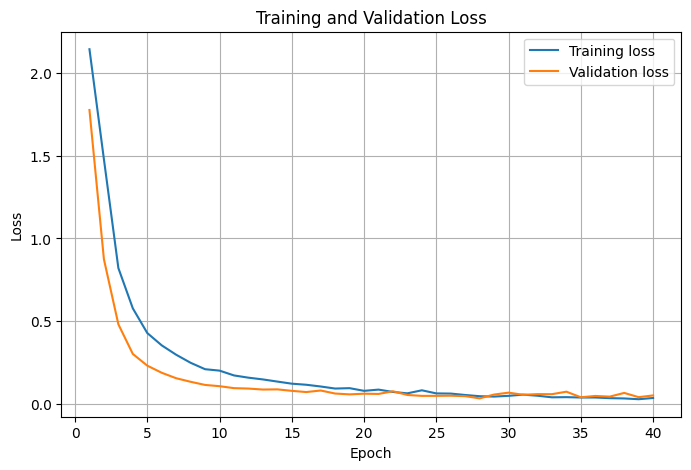

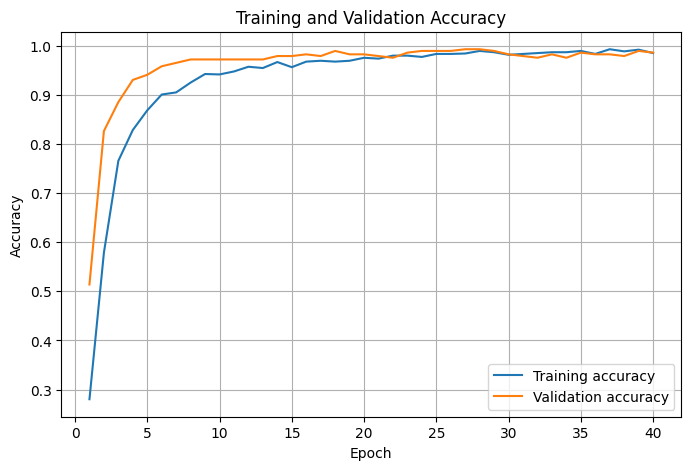

Saved loss curve to: /content/dnn_digits_project/artifacts/loss_curve.png
Saved accuracy curve to: /content/dnn_digits_project/artifacts/accuracy_curve.png


In [8]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ARTIFACT_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = ARTIFACT_DIR / "accuracy_curve.png"
plt.savefig(accuracy_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved loss curve to:", loss_plot_path)
print("Saved accuracy curve to:", accuracy_plot_path)

##9.TESTING

**Explanation for Cell 9**

This cell evaluates the model on the test set, which was not used during training or validation. This is the cleanest estimate of how the model performs on unseen examples. The confusion matrix shows which digits are classified correctly and which digits are confused with one another. The classification report provides precision, recall, and F1-score for each digit class.

Test loss: 0.0588
Test accuracy: 0.9806

Classification report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.89      0.93        35
           9       1.00      1.00      1.00        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



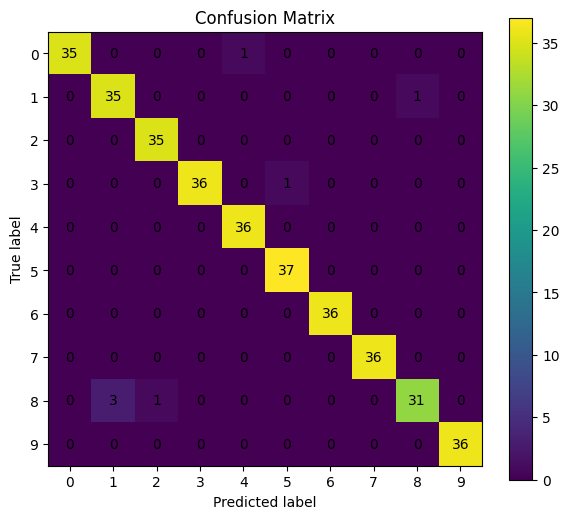

Evaluation summary saved to: /content/dnn_digits_project/artifacts/evaluation_summary.json
Confusion matrix saved to: /content/dnn_digits_project/artifacts/confusion_matrix.png


In [9]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
report_text = classification_report(y_test, y_pred, target_names=class_names)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

evaluation_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_manual": float(accuracy_score(y_test, y_pred)),
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist()
}

evaluation_path = ARTIFACT_DIR / "evaluation_summary.json"

with open(evaluation_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("\nClassification report")
print(report_text)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(10), class_names)
plt.yticks(np.arange(10), class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

confusion_matrix_path = ARTIFACT_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Evaluation summary saved to:", evaluation_path)
print("Confusion matrix saved to:", confusion_matrix_path)

##10.FINAL EVALUATION

**Explanation for Cell 10**

This final implementation cell inspects individual predictions and saves the trained model. Aggregate metrics are useful, but students also need to see concrete examples of success and failure. The cell identifies incorrect predictions, displays a sample of them, and stores a compact prediction table. This closes the implementation workflow by preserving artifacts that can be reviewed later.

In [ ]:
incorrect_indices = np.where(y_pred != y_test)[0]

prediction_records = []

for i in range(len(y_test)):
    record = {
        "test_index": int(i),
        "true_label": int(y_test[i]),
        "predicted_label": int(y_pred[i]),
        "predicted_probability": float(np.max(y_prob[i])),
        "correct": bool(y_pred[i] == y_test[i])
    }
    prediction_records.append(record)

predictions_path = ARTIFACT_DIR / "prediction_records.json"

with open(predictions_path, "w", encoding="utf-8") as f:
    json.dump(prediction_records, f, indent=2)

model_path = MODEL_DIR / "digits_dnn_model.keras"
model.save(model_path)

print("Number of incorrect predictions:", len(incorrect_indices))
print("Predictions saved to:", predictions_path)
print("Model saved to:", model_path)

if len(incorrect_indices) > 0:
    display_count = min(12, len(incorrect_indices))
    fig = plt.figure(figsize=(10, 4))

    for plot_position, test_index in enumerate(incorrect_indices[:display_count]):
        ax = fig.add_subplot(2, 6, plot_position + 1)
        ax.imshow(X_test[test_index].reshape(8, 8), cmap="gray")
        ax.set_title(f"True {y_test[test_index]} Pred {y_pred[test_index]}")
        ax.axis("off")

    plt.tight_layout()

    error_examples_path = ARTIFACT_DIR / "error_examples.png"
    plt.savefig(error_examples_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Error examples saved to:", error_examples_path)
else:
    print("The model made no errors on the test set.")

##11.SUMMARY

**Explanation for the LLM Results Cell**

This cell uses an OpenAI language model to explain the model and its results. The cell does not retrain the neural network. Instead, it reads the structured artifacts produced by the previous cells and asks the LLM to generate a governed explanation. The output is requested as JSON so that students can separate facts, assumptions, interpretation, and limitations. The API key is expected to be stored in the Colab Secrets section under the name OPENAI_API_KEY.

In [10]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(evaluation_path, "r", encoding="utf-8") as f:
    evaluation_for_llm = json.load(f)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

compact_results = {
    "run_id": RUN_ID,
    "dataset_summary": dataset_summary,
    "split_summary": split_summary,
    "model_name": model.name,
    "epochs_completed": len(history_for_llm["loss"]),
    "final_training_loss": history_for_llm["loss"][-1],
    "final_validation_loss": history_for_llm["val_loss"][-1],
    "final_training_accuracy": history_for_llm["accuracy"][-1],
    "final_validation_accuracy": history_for_llm["val_accuracy"][-1],
    "test_loss": evaluation_for_llm["test_loss"],
    "test_accuracy": evaluation_for_llm["test_accuracy"],
    "confusion_matrix": evaluation_for_llm["confusion_matrix"],
    "classification_report": evaluation_for_llm["classification_report"]
}

system_prompt = """
You are a machine learning instructor.
Explain a deep neural network experiment for handwritten digit recognition.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "model_explanation": "string",
  "results_explanation": "string",
  "best_performing_classes": ["string"],
  "weakest_or_most_confused_classes": ["string"],
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

{
  "plain_english_summary": "A deep neural network was trained to recognize 8x8 handwritten digits (0\u20139) from 1,797 samples. After 40 epochs, it achieved 98.06% accuracy on a 360-sample test set. Most digits were classified perfectly, with the main weakness being digit '8', which was sometimes mistaken for '1' or '2'.",
  "model_explanation": "This experiment uses a deep neural network classifier for handwritten digit recognition. Each image is represented by 64 input features (an 8x8 pixel grid flattened into a vector). The network is trained for 40 epochs to predict one of 10 classes ('0' through '9'), learning a mapping from pixel intensities to digit labels by minimizing a training loss and monitoring validation loss/accuracy.",
  "results_explanation": "Observed performance is strong and consistent across splits: final training accuracy is 0.9852 and final validation accuracy is 0.9861, with test accuracy 0.9806 (test loss 0.0588). The confusion matrix shows very few errors 

##12.CONCLUSIONS



This notebook has presented a complete introductory deep learning experiment using the handwritten digits problem. The goal was not only to train a classifier, but to teach the full structure of a machine learning workflow in a disciplined and repeatable format. Students began by preparing the environment, setting random seeds, creating output folders, and recording a manifest. This matters because machine learning should not be treated as an informal sequence of disconnected code fragments. It should be treated as an experiment with inputs, configuration, outputs, and artifacts.

The digits dataset allowed us to move from intuition to implementation. Each handwritten digit was represented as an 8 by 8 grayscale image, then converted into 64 numerical features. This transformation is one of the fundamental ideas of machine learning: real-world objects must be represented in mathematical form before a model can process them. The notebook then scaled the features, encoded the labels, and separated the data into training, validation, and test sets. That separation is essential because the central question is not whether the model can memorize examples it has already seen, but whether it can generalize to new examples.

The model itself was a fully connected deep neural network. It used multiple dense layers, ReLU activations, dropout regularization, and a softmax output layer. This architecture teaches the basic grammar of neural networks. Inputs enter the network, hidden layers transform them, nonlinearities allow the model to learn complex patterns, and the final layer converts internal representations into class probabilities. The training process used categorical cross-entropy as the loss function and Adam as the optimizer. These choices are standard for multiclass classification and make the notebook a natural bridge to more advanced neural network examples.

The evaluation section demonstrated that accuracy alone is not enough. Accuracy gives a useful headline number, but the confusion matrix and classification report provide deeper insight. They show which digits are reliably classified and which digits are more likely to be confused. This is an important lesson for students: machine learning results must be interpreted, not merely reported. A model with high average accuracy may still have specific weaknesses that matter in practice.

The final LLM explanation cell introduced a modern workflow pattern: numerical modeling combined with governed narrative explanation. The neural network produced the predictions and metrics. The language model converted those results into a structured interpretation, separating facts, assumptions, limitations, and next steps. This reinforces a key principle for the entire project: AI systems should produce artifacts that are inspectable, auditable, and reviewable by humans.

This 10 cell plus 1 format will be reused throughout the project. Each notebook will include an introduction, a sequence of implementation cells, a dedicated LLM explanation cell, and a conclusion. The structure is intentionally repetitive because repetition creates learning discipline. Students should come to recognize the pattern: define the problem, load the data, inspect the data, preprocess it, build the model, train it, evaluate it, interpret it, and document the results. The handwritten digits problem is therefore the ideal foundation. It is simple, visual, rigorous, and complete.